In [1]:
import re
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt

#Función que permite procesar el log asociado a un experimento y devuelve 3 elementos, el resumen del rendimiento en cada dataset, las estadisticas globales y el accuracy por clase en cada dataset
def procesar_log_detallado(ruta_archivo):

    #Abrimos el archivo en modo lectura
    try:
        with open(ruta_archivo, 'r', encoding='utf-8') as f:
            texto = f.read()
    except FileNotFoundError:
        return f"Error: No se encontró el archivo {ruta_archivo}", None, None

    #Separamos el log por secciones asociadas a cada dataset (cada prueba sobre un dataset comienza por 20 * y la frase "Ejecutando prueba sobre el dataset " y el nombre del dataset)
    secciones = re.split(r"\*{20,}Ejecutando prueba sobre el dataset", texto)
    
    resumen_data = []
    clases_data = []
    
    #Recorremos las secciones del log asociadas a cada dataset
    for seccion in secciones[1:]:
        #1. Obtenemos el nombre del dataset
        lineas = seccion.strip().split('\n')
        dataset_name = lineas[0].split('*')[0].strip()
        
        #2. Extraemos el OA y AA finales obtenidos sobre el dataset (OA Final y AA FInal)
        oa_match = re.search(r"OA Final:\s*([\d.]+)%\s*±\s*([\d.]+)%", seccion)
        aa_match = re.search(r"AA Final:\s*([\d.]+)%\s*±\s*([\d.]+)%", seccion)
        
        #Si se han encontrado el OA y el AA se añaden al resumen de resultados junto al nombre del dataset
        if oa_match and aa_match:
            resumen_data.append({
                "Dataset": dataset_name,
                "OA (%)": float(oa_match.group(1)),
                "AA (%)": float(aa_match.group(1))
            })
            
        #3. Extraemos el accuracy obtenido para cada clase (presentes en la subsección Accuracy por clase, la cual acaba con guines (-----))
        bloque_clases = re.search(r"ACCURACY POR CLASE:(.*?)---", seccion, re.DOTALL)
        if bloque_clases:
            #Obtenemos los resultados para cada clase
            matches_clase = re.findall(r"Clase (\d+):\s*([\d.]+)%", bloque_clases.group(1))
            #Almacenamos el accuracy asociado a cada una de las clases
            for num_clase, valor_acc in matches_clase:
                clases_data.append({
                    "Dataset": dataset_name,
                    "Clase": f"Clase {num_clase}",
                    "Accuracy (%)": float(valor_acc)
                })
    
    #Si no se han encontrado datos válidos se devuelve un mensaje de error.
    if not resumen_data:
        return "No se encontraron datos válidos.", None, None

    #Convertimos las listas en dataframes
    df_resumen = pd.DataFrame(resumen_data)
    df_clases_long = pd.DataFrame(clases_data)
    
    #Transformamos la tabla de clases a formato ancho (Datasets en las filas y Clases en las columnas)
    df_clases_wide = df_clases_long.pivot(index='Dataset', columns='Clase', values='Accuracy (%)')
    
    #Calculamos las estadísticas globales obtenidas mediante los diversos datasets (el OA global y el AA global junto a la desviación estándar)
    stats = {
        "Métrica": ["OA Global", "AA Global"],
        "Media (%)": [df_resumen["OA (%)"].mean(), df_resumen["AA (%)"].mean()],
        "Desviación (%)": [df_resumen["OA (%)"].std(), df_resumen["AA (%)"].std()]
    }
    
    #Pasamos las estadísticas a un dataframe
    df_stats = pd.DataFrame(stats)
    
    return df_resumen, df_stats, df_clases_wide

In [9]:
def imprimirResultados(ruta_carpeta):
    #Obtenemos los ficheros que terminan en .log
    archivos = glob.glob(os.path.join(ruta_carpeta, "*.log"))

    datos_comparacion = []

    if not archivos:
        print(f"No se encontraron archivos .log en la carpeta '{ruta_carpeta}'.")
    else:
        #Recorremos cada uno de los archivos asociados a las distintas ejecuciones
        for archivo in archivos:
            #Obtenemos el nombre asociado a la prueba
            nombre_prueba = os.path.basename(archivo).replace(".log", "")
            
            print(f"\n{'='*30} ARCHIVO: {nombre_prueba} {'='*30}")
            
            #Procesamos el log asociado a la prueba
            df_res, df_st, df_clases = procesar_log_detallado(archivo)
            
            #Si se leyeron correctamente los datos pasamos a imprimirlos por pantalla y a almacenarlos en datos_comparacion para poder graficar los resultados
            if isinstance(df_res, pd.DataFrame):
                print("\n************* TABLA RESUMEN (OA/AA): *************")
                print(df_res.to_string(index=False))
                
                print("\n************* ACCURACY POR CLASE POR DATASET: *************")
                print(df_clases.fillna("-").to_string())
                
                print("\n************* ESTADÍSTICAS GLOBALES: *************")
                print(df_st.to_string(index=False))
                
                #Guardamos los datos necesarios para realizar la gráfica (medias y desviaciones)
                oa_global = df_st.loc[df_st['Métrica'] == 'OA Global', 'Media (%)'].values[0]
                aa_global = df_st.loc[df_st['Métrica'] == 'AA Global', 'Media (%)'].values[0]
                
                oa_std = df_st.loc[df_st['Métrica'] == 'OA Global', 'Desviación (%)'].values[0]
                aa_std = df_st.loc[df_st['Métrica'] == 'AA Global', 'Desviación (%)'].values[0]
                
                datos_comparacion.append({
                    "Prueba": nombre_prueba,
                    "OA Global (%)": oa_global,
                    "AA Global (%)": aa_global,
                    "OA Std (%)": oa_std,
                    "AA Std (%)": aa_std
                })
            else:
                print(df_res)
    
        return datos_comparacion

In [10]:
#Código para hacer las gráficas comparativas de los modelos
def graficaComparacionModelos(datos_comparacion):
    if datos_comparacion:
        df_comparacion = pd.DataFrame(datos_comparacion)
        
        #Creamos una figura con 2 subgráficas, una para la media del OA y el AA y otra para las desviaciones del OA y el AA
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

        #Gráfica de barras del OA medio y AA medio de las distintas pruebas
        df_comparacion.set_index('Prueba')[['OA Global (%)', 'AA Global (%)']].plot(
            kind='bar', 
            ax=ax1, #Dibujamos la gráfica en el primer espacio
            color=['#1f77b4', '#ff7f0e'],
            alpha=0.8
        )
        ax1.set_title('Media Precisión Global (OA y AA)', fontsize=14, fontweight='bold')
        ax1.set_ylabel('Precisión (%)')
        ax1.set_ylim(60, 100)
        ax1.grid(axis='y', linestyle='--', alpha=0.5)
        ax1.legend(loc='upper right')

        #Gráfica de barras con la desviación estándar asociada al OA y el AA
        df_comparacion.set_index('Prueba')[['OA Std (%)', 'AA Std (%)']].plot(
            kind='bar', 
            ax=ax2,#Dibujamos la gráfica en el segundo espacio
            color=['#2ca02c', '#d62728'], # Colores distintos (Verde y Rojo)
            alpha=0.8
        )
        ax2.set_title('Desviación estándar (OA y AA)', fontsize=14, fontweight='bold')
        ax2.set_ylabel('Variación (%)')

        ax2.grid(axis='y', linestyle='--', alpha=0.5)
        ax2.legend(loc='upper right')

        # 2. Ajustes finales de formato
        plt.xticks(rotation=45, ha='right')
        plt.xlabel('Experimentos')
        
        # Ajusta el espacio entre las dos gráficas para que no se pisen
        plt.tight_layout()
        plt.show()

## Resultados sin usar el aumentado de la clase minoritaria en el dataloader

In [11]:
#Leemos los resultados asociados a las ejecuciones sin usar el oversampling
ruta_carpeta = "Codigos_no_clase_minoritaria/resultadosPruebas"

datos_comparacion=imprimirResultados(ruta_carpeta)


============================== ARCHIVO: resultados_FMIX ==============================

************* TABLA RESUMEN (OA/AA): *************
        Dataset  OA (%)  AA (%)
        oitaven   95.61   92.08
     das_mestas   91.41   88.18
      eiras_dam   97.08   90.83
  ermidas_creek   98.50   96.30
ferreiras_river   91.82   77.98
     mera_river   90.84   81.54
           ulla   99.17   98.15
          xesta   98.57   90.75

************* ACCURACY POR CLASE POR DATASET: *************
Clase           Clase 01  Clase 02 Clase 03 Clase 04 Clase 05 Clase 06  Clase 07  Clase 08 Clase 09 Clase 10
Dataset                                                                                                     
das_mestas             -     70.19        -        -        -        -     92.80     95.16        -     94.6
eiras_dam          99.12     85.35    94.99    96.49    79.05    89.07     94.93     98.86    78.77    91.72
ermidas_creek      93.89     91.33    92.46    99.05    94.25    98.69     

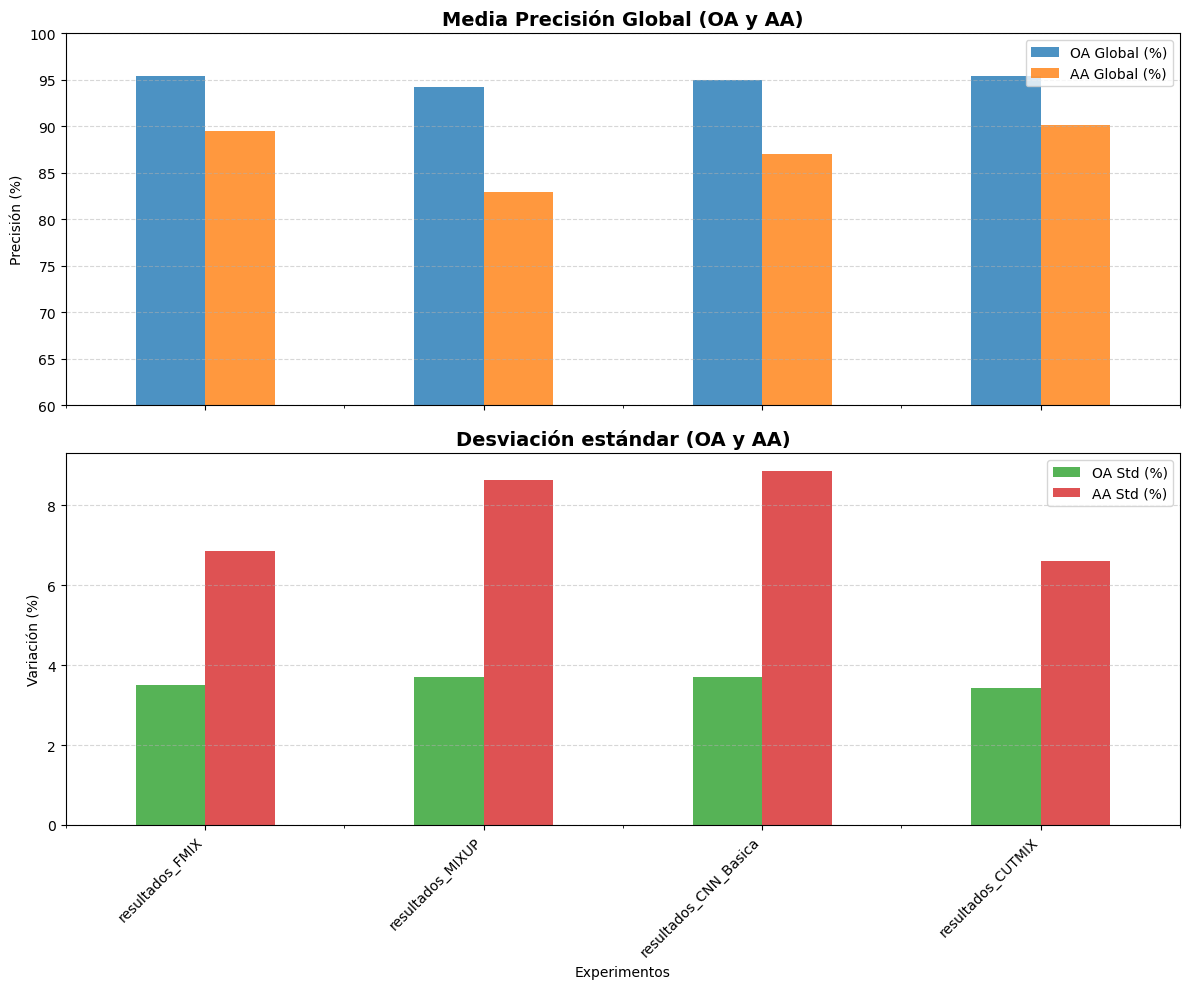

In [12]:
graficaComparacionModelos(datos_comparacion)

## Resultados usando el aumentado de la clase minoritaria en el dataloader

In [ ]:
# --- EJECUCIÓN ---
ruta_carpeta = "resultadosPruebas"

datos_comparacion=imprimirResultados(ruta_carpeta)


============================== ARCHIVO: resultados_FMIX ==============================

1. TABLA RESUMEN (OA/AA):
        Dataset  OA (%)  AA (%)
        oitaven   94.49   93.88
     das_mestas   90.50   90.11
      eiras_dam   95.81   94.06
  ermidas_creek   97.80   97.14
ferreiras_river   90.91   78.27
     mera_river   90.50   78.29
           ulla   99.01   99.01
          xesta   98.04   93.97

2. ACCURACY POR CLASE POR DATASET:
Clase           Clase 01  Clase 02 Clase 03 Clase 04 Clase 05 Clase 06  Clase 07  Clase 08 Clase 09 Clase 10
Dataset                                                                                                     
das_mestas             -     78.29        -        -        -        -     90.21     98.88        -    93.08
eiras_dam          99.08     90.35    95.16    98.55    85.29    99.67     95.44     95.28    92.27    89.55
ermidas_creek      95.31     93.75    94.18     98.6     98.2    98.35     97.85     97.96    99.33     97.9
ferreiras_river 



=== RESUMEN GLOBAL PARA GRÁFICA ===
               Prueba  OA Global (%)  AA Global (%)  OA Std (%)  AA Std (%)
      resultados_FMIX       94.63250       90.59125    3.590176    8.030220
     resultados_MIXUP       93.19625       84.85375    3.441233    8.601533
resultados_CNN_Basica       94.88000       88.83750    3.636513    8.587056
    resultados_CUTMIX       94.47875       91.54750    3.438673    7.007141


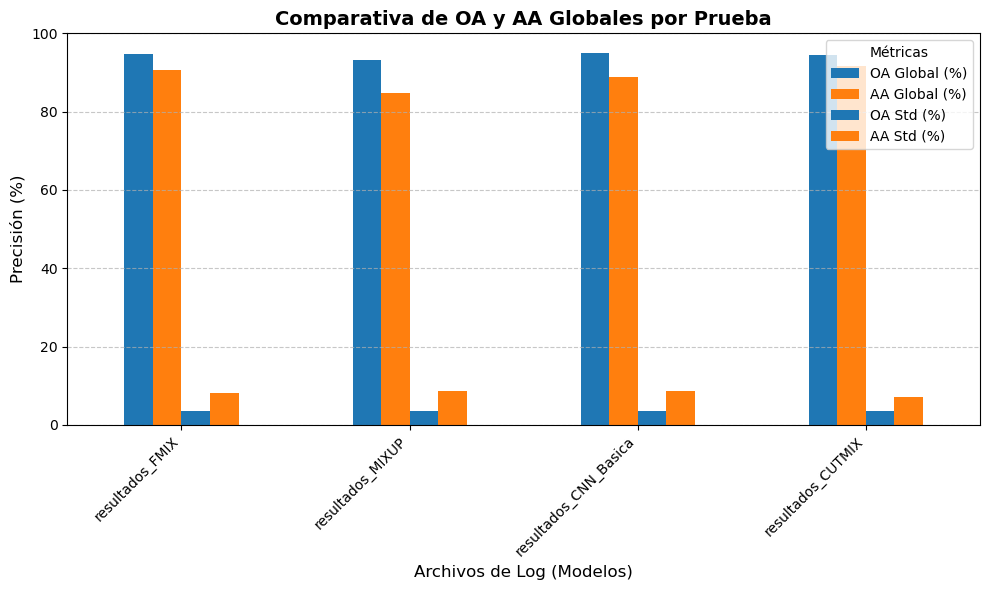

In [ ]:
graficaComparacionModelos(datos_comparacion)

## Comparación de cada versión


==================== COMPARANDO: resultados_CUTMIX ====================
Versión                           | OA Global (%)     | AA Global (%)
----------------------------------|-------------------|-------------------
Aumentado                         | 94.48 ± 3.44      | 91.55 ± 7.01
Sin Aumentado Clase Minoritaria   | 95.45 ± 3.43      | 90.15 ± 6.60

==================== COMPARANDO: resultados_MIXUP ====================
Versión                           | OA Global (%)     | AA Global (%)
----------------------------------|-------------------|-------------------
Aumentado                         | 93.20 ± 3.44      | 84.85 ± 8.60
Sin Aumentado Clase Minoritaria   | 94.19 ± 3.71      | 82.89 ± 8.64

==================== COMPARANDO: resultados_FMIX ====================
Versión                           | OA Global (%)     | AA Global (%)
----------------------------------|-------------------|-------------------
Aumentado                         | 94.63 ± 3.59      | 90.59 ± 8.03
Sin 

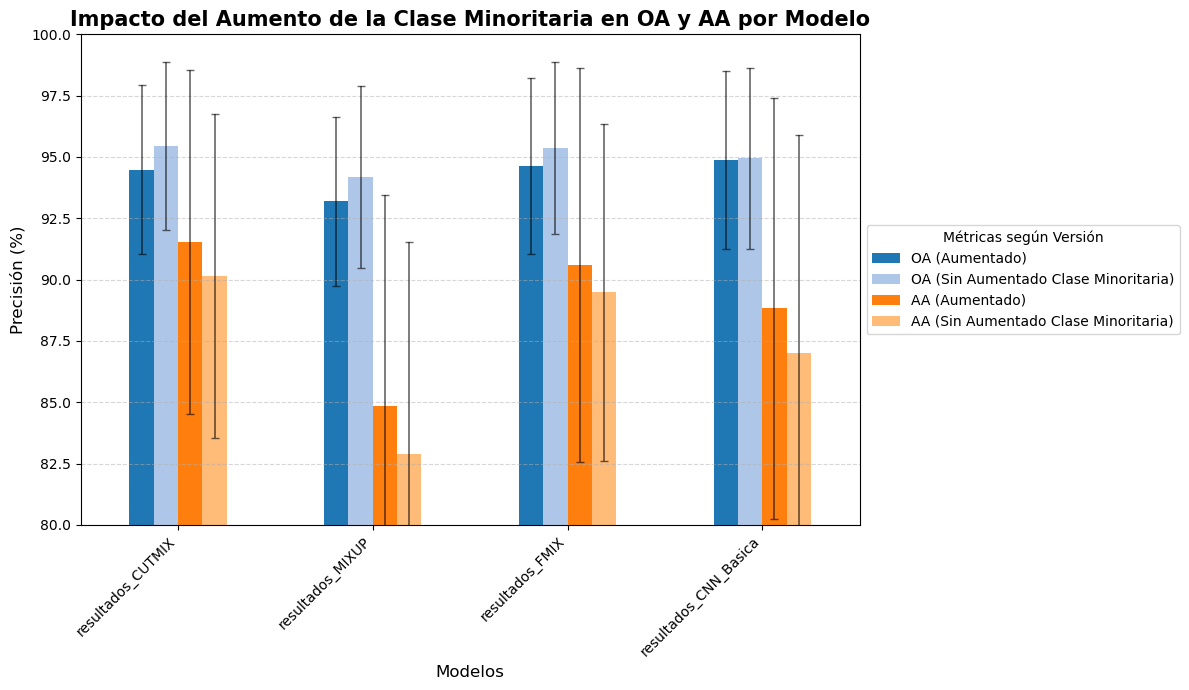

In [14]:
import re
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt

def procesar_log_detallado(ruta_archivo):
    # (La función de extracción se mantiene igual)
    try:
        with open(ruta_archivo, 'r', encoding='utf-8') as f:
            texto = f.read()
    except FileNotFoundError:
        return f"Error: No se encontró el archivo {ruta_archivo}", None, None

    secciones = re.split(r"\*{20,}Ejecutando prueba sobre el dataset", texto)
    resumen_data = []
    clases_data = []
    
    for seccion in secciones[1:]:
        lineas = seccion.strip().split('\n')
        dataset_name = lineas[0].split('*')[0].strip()
        
        oa_match = re.search(r"OA Final:\s*([\d.]+)%\s*±\s*([\d.]+)%", seccion)
        aa_match = re.search(r"AA Final:\s*([\d.]+)%\s*±\s*([\d.]+)%", seccion)
        
        if oa_match and aa_match:
            resumen_data.append({
                "Dataset": dataset_name,
                "OA (%)": float(oa_match.group(1)),
                "AA (%)": float(aa_match.group(1))
            })
            
        bloque_clases = re.search(r"ACCURACY POR CLASE:(.*?)---", seccion, re.DOTALL)
        if bloque_clases:
            matches_clase = re.findall(r"Clase (\d+):\s*([\d.]+)%", bloque_clases.group(1))
            for num_clase, valor_acc in matches_clase:
                clases_data.append({
                    "Dataset": dataset_name,
                    "Clase": f"Clase {num_clase}",
                    "Accuracy (%)": float(valor_acc)
                })

    if not resumen_data:
        return None, None, None

    df_resumen = pd.DataFrame(resumen_data)
    df_clases_long = pd.DataFrame(clases_data)
    df_clases_wide = df_clases_long.pivot(index='Dataset', columns='Clase', values='Accuracy (%)')
    
    stats = {
        "Métrica": ["OA Global", "AA Global"],
        "Media (%)": [df_resumen["OA (%)"].mean(), df_resumen["AA (%)"].mean()],
        "Desviación (%)": [df_resumen["OA (%)"].std(), df_resumen["AA (%)"].std()]
    }
    df_stats = pd.DataFrame(stats)
    
    return df_resumen, df_stats, df_clases_wide


# --- EJECUCIÓN Y COMPARACIÓN ---
carpeta_v1 = "resultadosPruebas" # Con aumentado (Aumentado)
carpeta_v2 = "Codigos_no_clase_minoritaria/resultadosPruebas" # Sin aumentado

# Obtenemos solo los nombres de archivo para buscar coincidencias
archivos_v1 = {os.path.basename(f) for f in glob.glob(os.path.join(carpeta_v1, "*.log"))}
archivos_v2 = {os.path.basename(f) for f in glob.glob(os.path.join(carpeta_v2, "*.log"))}

# Intersección: Solo analizamos los logs que existen en ambas carpetas
archivos_comunes = list(archivos_v1.intersection(archivos_v2))
datos_comparacion = []

if not archivos_comunes:
    print("No se encontraron archivos .log coincidentes entre ambas carpetas.")
else:
    for archivo_nombre in archivos_comunes:
        nombre_prueba = archivo_nombre.replace(".log", "")
        ruta_v1 = os.path.join(carpeta_v1, archivo_nombre)
        ruta_v2 = os.path.join(carpeta_v2, archivo_nombre)
        
        # Procesamos ambos archivos
        _, df_st_v1, _ = procesar_log_detallado(ruta_v1)
        _, df_st_v2, _ = procesar_log_detallado(ruta_v2)
        
        if df_st_v1 is not None and df_st_v2 is not None:
            # Extraemos datos V1 (Aumentado)
            oa_v1 = df_st_v1.loc[df_st_v1['Métrica'] == 'OA Global', 'Media (%)'].values[0]
            aa_v1 = df_st_v1.loc[df_st_v1['Métrica'] == 'AA Global', 'Media (%)'].values[0]
            oa_std_v1 = df_st_v1.loc[df_st_v1['Métrica'] == 'OA Global', 'Desviación (%)'].values[0]
            aa_std_v1 = df_st_v1.loc[df_st_v1['Métrica'] == 'AA Global', 'Desviación (%)'].values[0]
            
            # Extraemos datos V2 (Sin Aumentado)
            oa_v2 = df_st_v2.loc[df_st_v2['Métrica'] == 'OA Global', 'Media (%)'].values[0]
            aa_v2 = df_st_v2.loc[df_st_v2['Métrica'] == 'AA Global', 'Media (%)'].values[0]
            oa_std_v2 = df_st_v2.loc[df_st_v2['Métrica'] == 'OA Global', 'Desviación (%)'].values[0]
            aa_std_v2 = df_st_v2.loc[df_st_v2['Métrica'] == 'AA Global', 'Desviación (%)'].values[0]
            
            # Imprimimos comparación uno a uno en consola con anchos ajustados
            print(f"\n{'='*20} COMPARANDO: {nombre_prueba} {'='*20}")
            print(f"Versión                           | OA Global (%)     | AA Global (%)")
            print(f"----------------------------------|-------------------|-------------------")
            print(f"Aumentado                         | {oa_v1:5.2f} ± {oa_std_v1:4.2f}      | {aa_v1:5.2f} ± {aa_std_v1:4.2f}")
            print(f"Sin Aumentado Clase Minoritaria   | {oa_v2:5.2f} ± {oa_std_v2:4.2f}      | {aa_v2:5.2f} ± {aa_std_v2:4.2f}")
            
            # Guardamos para el DataFrame final
            datos_comparacion.append({
                "Prueba": nombre_prueba,
                "OA_Orig": oa_v1, "OA_SinAum": oa_v2,
                "AA_Orig": aa_v1, "AA_SinAum": aa_v2,
                "OA_Std_Orig": oa_std_v1, "OA_Std_SinAum": oa_std_v2,
                "AA_Std_Orig": aa_std_v1, "AA_Std_SinAum": aa_std_v2
            })

# --- GRÁFICA Y TABLA COMPARATIVA GLOBAL ---
if datos_comparacion:
    df_comp = pd.DataFrame(datos_comparacion)
    
    print("\n\n" + "="*80)
    print("=== TABLA RESUMEN GLOBAL DE COMPARACIÓN ===")
    print("="*80)
    # Mostramos una versión simplificada de la tabla
    df_mostrar = df_comp[['Prueba', 'OA_Orig', 'OA_SinAum', 'AA_Orig', 'AA_SinAum']].copy()
    df_mostrar.columns = ['Prueba', 'OA (Aumentado)', 'OA (Sin Aumentado Clase Minoritaria)', 'AA (Aumentado)', 'AA (Sin Aumentado Clase Minoritaria)']
    print(df_mostrar.to_string(index=False))
    
    # Preparamos los DataFrames para graficar
    df_medias = df_comp[['Prueba', 'OA_Orig', 'OA_SinAum', 'AA_Orig', 'AA_SinAum']].set_index('Prueba')
    df_errores = df_comp[['Prueba', 'OA_Std_Orig', 'OA_Std_SinAum', 'AA_Std_Orig', 'AA_Std_SinAum']].set_index('Prueba')
    
    # Actualizamos los nombres para la leyenda de la gráfica
    columnas_limpias = [
        'OA (Aumentado)', 
        'OA (Sin Aumentado Clase Minoritaria)', 
        'AA (Aumentado)', 
        'AA (Sin Aumentado Clase Minoritaria)'
    ]
    df_medias.columns = columnas_limpias
    df_errores.columns = columnas_limpias
    
    # Colores
    colores = ['#1f77b4', '#aec7e8', '#ff7f0e', '#ffbb78']
    
    # Graficar
    df_medias.plot(
        kind='bar', 
        yerr=df_errores,
        capsize=3,
        error_kw={'alpha': 0.6, 'lw': 1.2},
        figsize=(12, 7), 
        color=colores
    )
    
    plt.title('Impacto del Aumento de la Clase Minoritaria en OA y AA por Modelo', fontsize=15, fontweight='bold')
    plt.xlabel('Modelos', fontsize=12)
    plt.ylabel('Precisión (%)', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.ylim(80, 100)
    # Movemos un poco la leyenda para que el texto largo no tape las barras
    plt.legend(title='Métricas según Versión', loc='center left', bbox_to_anchor=(1, 0.5))
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()